# Analisis Data Sekolah Provinsi Jawa Timur (Versi 2.0)

Notebook ini berisi analisis data jumlah sekolah di Jawa Timur berdasarkan data resmi dari BPS (`Seluruh Sekolah_Jatim.csv`).
Analisis ini difokuskan pada distribusi jumlah sekolah negeri vs swasta, serta pemetaan berdasarkan wilayah (Kabupaten/Kota) tanpa menggunakan data demografis yang disintesis/palsu.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import json

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

## 1. Data Loading dan Preprocessing
Membaca file CSV yang memiliki format multi-header dan memperbaikinya agar mudah diolah.

In [11]:
# Membaca baris header saja untuk menentukan nama kolom yang benar
df_header = pd.read_csv('Seluruh Sekolah_Jatim.csv', header=None, nrows=2)

header1 = df_header.iloc[0].ffill()  # Mengisi NaN ke kanan (misal: TK, TK, TK menjadi TK)
header2 = df_header.iloc[1].fillna('')

new_columns = []
for h1, h2 in zip(header1, header2):
    if pd.isna(h1) or h1 in ['No', 'Wilayah']:
        new_columns.append(str(h1))
    else:
        suffix = '_Total' if h2 == 'Jml' else ('_Negeri' if h2 == 'N' else ('_Swasta' if h2 == 'S' else ''))
        new_columns.append(f"{h1}{suffix}")

# Load data dengan mengabaikan 2 baris pertama, gunakan kolom baru
df = pd.read_csv('Seluruh Sekolah_Jatim.csv', skiprows=2, names=new_columns)

# Menghapus baris 'Total' di bagian bawah jika ada
df = df.dropna(subset=['Wilayah'])
df = df[df['Wilayah'] != 'Total'].copy()

# Format angka di CSV Indonesia biasanya memakai '.' untuk ribuan.
# Kita hilangkan '.' dan ubah ke numeric.
numeric_cols = [c for c in df.columns if c not in ['No', 'Wilayah']]
for col in numeric_cols:
    df[col] = df[col].astype(str).str.replace('.', '', regex=False)
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

df['Tipe_Wilayah'] = df['Wilayah'].apply(lambda x: 'Kota' if 'Kota' in str(x) else 'Kabupaten')

print(f"Data berhasil dimuat. Total baris: {len(df)}")
display(df.head())

Data berhasil dimuat. Total baris: 38


,No,Wilayah,Total_Total,Total_Negeri,Total_Swasta,TK_Total,TK_Negeri,TK_Swasta,KB_Total,KB_Negeri,...,SMA_Total,SMA_Negeri,SMA_Swasta,SMK_Total,SMK_Negeri,SMK_Swasta,SLB_Total,SLB_Negeri,SLB_Swasta,Tipe_Wilayah
0,1,Kota Surabaya,3837,3860,3451,1251,3,1248,3870,1,...,1400,23,1170,1060,11,950,40,0,40,Kota
1,2,Kab. Malang,3563,1186,2377,1008,4,1004,7260,0,...,730,13,600,1430,9,1340,13,1,12,Kabupaten
2,3,Kab. Jember,3507,1035,2472,9620,6,9560,5070,0,...,630,18,450,1820,8,1740,10,2,8,Kabupaten
3,4,Kab. Lamongan,3359,6650,2694,1006,2,1004,1098,0,...,700,14,560,790,7,720,9,1,8,Kabupaten
4,5,Kab. Bojonegoro,2831,7980,2033,6710,4,6670,5710,0,...,510,21,300,610,19,420,13,7,6,Kabupaten


## 2. Analisis Distribusi Total Sekolah (Negeri vs Swasta)

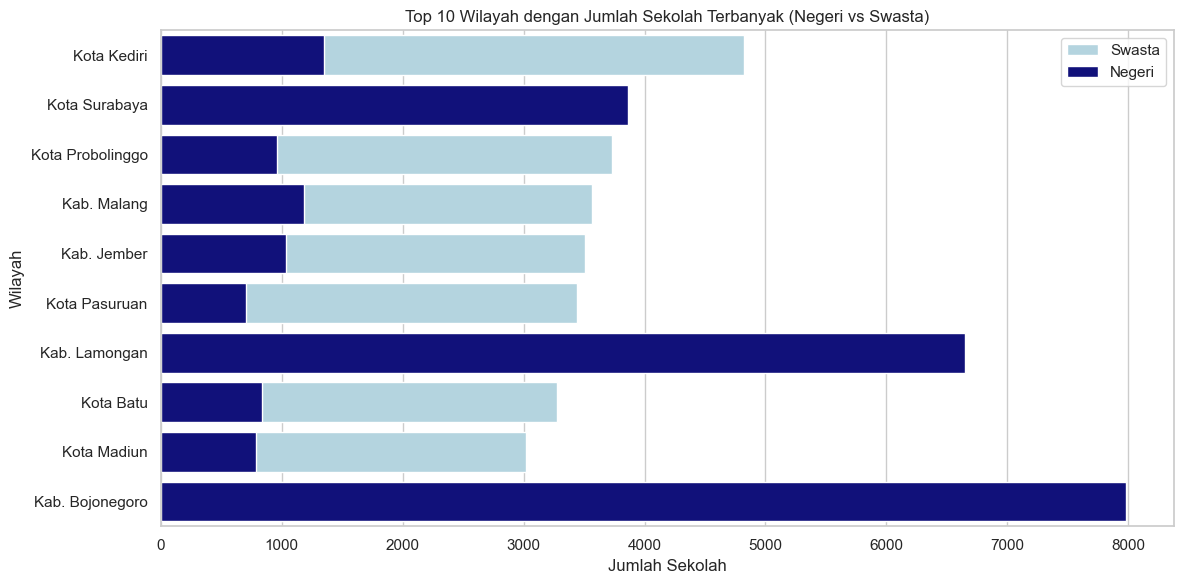

In [12]:
# Menghitung persentase sekolah negeri dan swasta per wilayah
df['Persentase_Negeri'] = (df['Total_Negeri'] / df['Total_Total']) * 100
df['Persentase_Swasta'] = (df['Total_Swasta'] / df['Total_Total']) * 100

# Visualisasi Top 10 Wilayah dengan Sekolah Terbanyak
top_10 = df.nlargest(10, 'Total_Total')

plt.figure(figsize=(12, 6))
sns.barplot(data=top_10, x='Total_Total', y='Wilayah', color='lightblue', label='Swasta')
sns.barplot(data=top_10, x='Total_Negeri', y='Wilayah', color='darkblue', label='Negeri')
plt.title('Top 10 Wilayah dengan Jumlah Sekolah Terbanyak (Negeri vs Swasta)')
plt.xlabel('Jumlah Sekolah')
plt.ylabel('Wilayah')
plt.legend()
plt.tight_layout()
plt.show()

## 3. Komparasi Kota vs Kabupaten
Apakah terdapat perbedaan rasio sekolah negeri dan swasta antara wilayah Kota dan Kabupaten?

<Figure size 800x600 with 0 Axes>

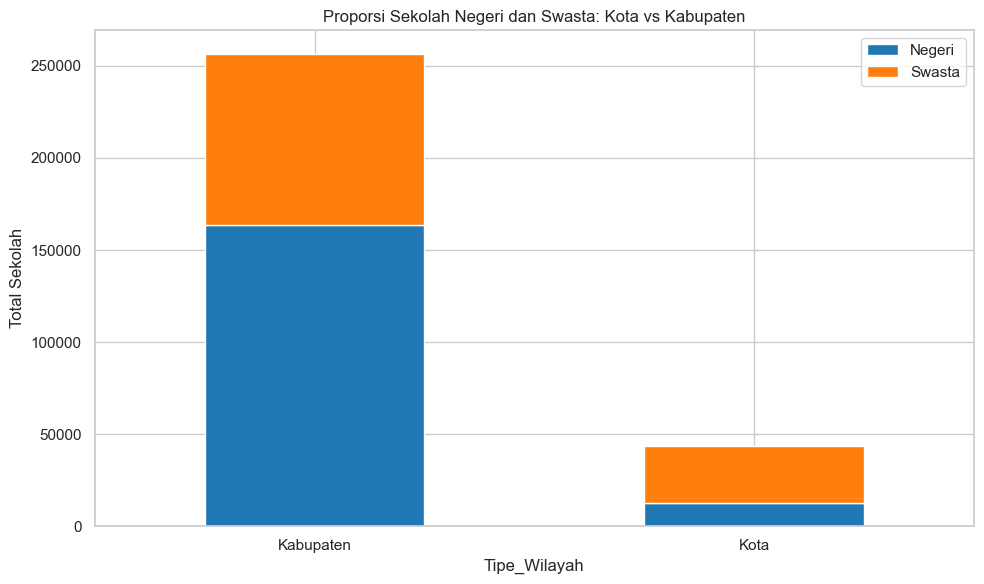

In [13]:
komparasi = df.groupby('Tipe_Wilayah')[['Total_Negeri', 'Total_Swasta']].sum().reset_index()

plt.figure(figsize=(8, 6))
komparasi.set_index('Tipe_Wilayah').plot(kind='bar', stacked=True, color=['#1f77b4', '#ff7f0e'], figsize=(10, 6))
plt.title('Proporsi Sekolah Negeri dan Swasta: Kota vs Kabupaten')
plt.ylabel('Total Sekolah')
plt.xticks(rotation=0)
plt.legend(['Negeri', 'Swasta'])
plt.tight_layout()
plt.show()

## 4. Distribusi Berdasarkan Jenjang Pendidikan (SD, SMP, SMA, SMK)

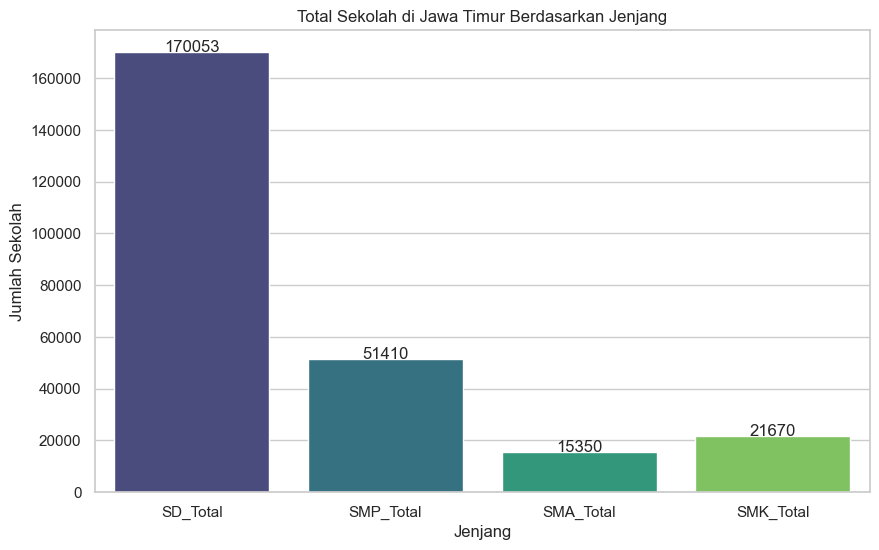

In [14]:
jenjang = ['SD_Total', 'SMP_Total', 'SMA_Total', 'SMK_Total']
df_jenjang = df[['Wilayah'] + jenjang].set_index('Wilayah')
df_jenjang_sum = df_jenjang.sum().reset_index()
df_jenjang_sum.columns = ['Jenjang', 'Total']

plt.figure(figsize=(10, 6))
sns.barplot(data=df_jenjang_sum, x='Jenjang', y='Total', palette='viridis')
plt.title('Total Sekolah di Jawa Timur Berdasarkan Jenjang')
plt.ylabel('Jumlah Sekolah')
for i, v in enumerate(df_jenjang_sum['Total']):
    plt.text(i, v + 200, str(int(v)), ha='center')
plt.show()

## 5. Pemetaan Spasial (Titik Sampel)
Memvisualisasikan sebaran sampel titik sekolah dari file `jatim.geojson`.
*(Catatan: jatim.geojson ternyata berisi koordinat titik spesifik dari 420 sekolah, bukan batas regional untuk pembuatan peta Choropleth)*

In [15]:
try:
    with open('jatim.geojson', 'r') as f:
        geojson_jatim = json.load(f)
    
    lats = []
    lons = []
    names = []
    for feature in geojson_jatim['features']:
        coords = feature['geometry']['coordinates']
        lons.append(coords[0])
        lats.append(coords[1])
        names.append(feature['properties'].get('name', 'Unknown'))
    
    fig = px.scatter_mapbox(
        lat=lats, lon=lons, hover_name=names,
        color_discrete_sequence=['fuchsia'], zoom=6, center={"lat": -7.7, "lon": 112.5},
        mapbox_style="carto-positron",
        title="Peta Persebaran 420 Titik Sekolah di Jawa Timur (Data Sampel GeoJSON)"
    )
    fig.update_layout(margin={"r":0,"t":40,"l":0,"b":0})
    fig.show()
except Exception as e:
    print('Map tidak dapat dirender:', e)


## 6. Analisis Hotspot dan Coldspot Wilayah
Identifikasi Kabupaten/Kota mana saja yang merupakan pusat kepadatan sekolah (Hotspot) dan wilayah dengan jumlah sekolah paling sedikit (Coldspot).

In [16]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Mengambil Top 5 (Hotspot) dan Bottom 5 (Coldspot) Kabupaten/Kota
df_sorted = df.sort_values('Total_Total', ascending=False)
hotspots = df_sorted.head(5)
coldspots = df_sorted.tail(5)

fig = make_subplots(rows=1, cols=2, subplot_titles=('🔥 Hotspots (Top 5 Tertinggi)', '❄️ Coldspots (Top 5 Terendah)'))

fig.add_trace(go.Bar(
    x=hotspots['Wilayah'], 
    y=hotspots['Total_Total'],
    marker_color='crimson',
    name='Hotspot'
), row=1, col=1)

fig.add_trace(go.Bar(
    x=coldspots['Wilayah'], 
    y=coldspots['Total_Total'],
    marker_color='royalblue',
    name='Coldspot'
), row=1, col=2)

fig.update_layout(
    title_text="Hotspot vs Coldspot Persebaran Sekolah di Jawa Timur",
    showlegend=False,
    height=500
)
fig.show()

### Peta Kepadatan Spasial (Horizontal Layout)
Visualisasi geografis dengan memetakan jumlah sekolah secara proporsional sebagai ukuran bubble (gelembung), dipecah menjadi 3 aspek: Total Sekolah, Negeri, dan Swasta.

In [19]:
# TAHAP 4: VISUALISASI GEOSPASIAL KOMPREHENSIF - HORIZONTAL LAYOUT
print("🗺️ VISUALISASI GEOSPASIAL")
print("=" * 50)

# Coordinate mapping for East Java regions (enhanced)
region_coordinates = {
    'Kota Surabaya': (-7.257, 112.750),
    'Kota Malang': (-7.977, 112.635),
    'Kota Kediri': (-7.811, 112.003),
    'Kota Mojokerto': (-7.474, 112.435),
    'Kota Blitar': (-8.100, 112.181),
    'Kota Pasuruan': (-7.638, 112.904),
    'Kota Probolinggo': (-7.755, 113.196),
    'Kota Batu': (-7.879, 112.528),
    'Kota Madiun': (-7.631, 111.531),
    'Kab. Gresik': (-7.168, 112.653),
    'Kab. Sidoarjo': (-7.435, 112.722),
    'Kab. Jember': (-8.171, 113.703),
    'Kab. Lamongan': (-7.113, 112.414),
    'Kab. Bojonegoro': (-7.154, 111.882),
    'Kab. Tuban': (-6.897, 111.964),
    'Kab. Jombang': (-7.546, 112.234),
    'Kab. Nganjuk': (-7.605, 111.904),
    'Kab. Magetan': (-7.647, 111.350),
    'Kab. Ponorogo': (-7.874, 111.462),
    'Kab. Pacitan': (-8.205, 111.092),
    'Kab. Trenggalek': (-8.051, 111.708),
    'Kab. Tulungagung': (-8.064, 111.902),
    'Kab. Lumajang': (-8.133, 113.225),
    'Kab. Bondowoso': (-7.913, 113.822),
    'Kab. Situbondo': (-7.706, 114.010),
    'Kab. Banyuwangi': (-8.219, 114.369),
    'Kab. Pamekasan': (-7.156, 113.476),
    'Kab. Sampang': (-7.047, 113.239),
    'Kab. Sumenep': (-7.017, 113.854),
    'Kab. Bangkalan': (-7.045, 112.739),
    'Kab. Kediri': (-7.848, 112.018),
    'Kab. Malang': (-8.026, 112.652),
    'Kab. Pasuruan': (-7.745, 112.907),
    'Kab. Probolinggo': (-7.724, 113.215),
    'Kab. Mojokerto': (-7.553, 112.434),
    'Kab. Blitar': (-8.097, 112.165)
}

# Prepare visualization data dengan data sekolah negeri dan swasta
viz_data = []
unmatched_regions = []

for idx, row in df.iterrows():
    wilayah = row['Wilayah']
    
    if wilayah in region_coordinates:
        lat, lon = region_coordinates[wilayah]
        viz_data.append({
            'wilayah': wilayah,
            'latitude': lat,
            'longitude': lon,
            'total_schools': row['Total_Total'],
            'total_negeri': row['Total_Negeri'],  # Kolom negeri dari df Analisis 2.0
            'total_swasta': row['Total_Swasta'],  # Kolom swasta dari df Analisis 2.0
            'tipe_wilayah': row['Tipe_Wilayah']
        })
    else:
        unmatched_regions.append(wilayah)

viz_df = pd.DataFrame(viz_data)

print(f"✅ Data visualisasi disiapkan untuk {len(viz_df)} wilayah")
if unmatched_regions:
    print(f"⚠️ Wilayah tanpa koordinat: {unmatched_regions}")

# Pisahkan data kota dan kabupaten
# Perhatikan casing 'Kota' dan 'Kabupaten' (di Analisis 2.0 Tipe_Wilayah = 'Kota'/'Kabupaten')
kota_df = viz_df[viz_df['tipe_wilayah'] == 'Kota'].copy()
kab_df = viz_df[viz_df['tipe_wilayah'] == 'Kabupaten'].copy()

# Create comprehensive visualization dengan 3 peta dalam bentuk horizontal (1 baris, 3 kolom)
fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=(
        'Total Sekolah: Kabupaten vs Kota',
        'Sekolah Negeri: Kabupaten vs Kota', 
        'Sekolah Swasta: Kabupaten vs Kota'
    ),
    specs=[[{"type": "mapbox"}, {"type": "mapbox"}, {"type": "mapbox"}]],
    horizontal_spacing=0.02
)

# Calculate bubble sizes untuk setiap metrik
def calculate_bubble_size(data_col, min_size=8, max_size=30):
    if data_col.max() == data_col.min():
        return [min_size] * len(data_col)
    normalized = (data_col - data_col.min()) / (data_col.max() - data_col.min())
    return min_size + normalized * (max_size - min_size)

# PETA 1: Total Sekolah
kota_df['bubble_size_total'] = calculate_bubble_size(kota_df['total_schools'])
kab_df['bubble_size_total'] = calculate_bubble_size(kab_df['total_schools'])

# Kabupaten
fig.add_trace(
    go.Scattermapbox(
        lat=kab_df['latitude'],
        lon=kab_df['longitude'],
        mode='markers',
        marker=dict(
            size=kab_df['bubble_size_total'],
            color='red',
            opacity=0.7,
            sizemode='diameter'
        ),
        text=[f"<b>{w}</b><br>Total: {int(s):,} sekolah<br>Tipe: Kabupaten" 
              for w, s in zip(kab_df['wilayah'], kab_df['total_schools'])],
        hovertemplate='%{text}<extra></extra>',
        name='Kabupaten',
        legendgroup="group1",
        showlegend=True
    ),
    row=1, col=1
)

# Kota
fig.add_trace(
    go.Scattermapbox(
        lat=kota_df['latitude'],
        lon=kota_df['longitude'],
        mode='markers',
        marker=dict(
            size=kota_df['bubble_size_total'],
            color='blue',
            opacity=0.8,
            sizemode='diameter'
        ),
        text=[f"<b>{w}</b><br>Total: {int(s):,} sekolah<br>Tipe: Kota" 
              for w, s in zip(kota_df['wilayah'], kota_df['total_schools'])],
        hovertemplate='%{text}<extra></extra>',
        name='Kota',
        legendgroup="group1",
        showlegend=True
    ),
    row=1, col=1
)

# PETA 2: Sekolah Negeri
kota_df['bubble_size_negeri'] = calculate_bubble_size(kota_df['total_negeri'])
kab_df['bubble_size_negeri'] = calculate_bubble_size(kab_df['total_negeri'])

# Kabupaten Negeri
fig.add_trace(
    go.Scattermapbox(
        lat=kab_df['latitude'],
        lon=kab_df['longitude'],
        mode='markers',
        marker=dict(
            size=kab_df['bubble_size_negeri'],
            color='darkred',
            opacity=0.7,
            sizemode='diameter'
        ),
        text=[f"<b>{w}</b><br>Negeri: {int(s):,} sekolah<br>Tipe: Kabupaten" 
              for w, s in zip(kab_df['wilayah'], kab_df['total_negeri'])],
        hovertemplate='%{text}<extra></extra>',
        name='Kabupaten',
        legendgroup="group2",
        showlegend=False
    ),
    row=1, col=2
)

# Kota Negeri
fig.add_trace(
    go.Scattermapbox(
        lat=kota_df['latitude'],
        lon=kota_df['longitude'],
        mode='markers',
        marker=dict(
            size=kota_df['bubble_size_negeri'],
            color='darkblue',
            opacity=0.8,
            sizemode='diameter'
        ),
        text=[f"<b>{w}</b><br>Negeri: {int(s):,} sekolah<br>Tipe: Kota" 
              for w, s in zip(kota_df['wilayah'], kota_df['total_negeri'])],
        hovertemplate='%{text}<extra></extra>',
        name='Kota',
        legendgroup="group2",
        showlegend=False
    ),
    row=1, col=2
)

# PETA 3: Sekolah Swasta
kota_df['bubble_size_swasta'] = calculate_bubble_size(kota_df['total_swasta'])
kab_df['bubble_size_swasta'] = calculate_bubble_size(kab_df['total_swasta'])

# Kabupaten Swasta
fig.add_trace(
    go.Scattermapbox(
        lat=kab_df['latitude'],
        lon=kab_df['longitude'],
        mode='markers',
        marker=dict(
            size=kab_df['bubble_size_swasta'],
            color='orange',
            opacity=0.7,
            sizemode='diameter'
        ),
        text=[f"<b>{w}</b><br>Swasta: {int(s):,} sekolah<br>Tipe: Kabupaten" 
              for w, s in zip(kab_df['wilayah'], kab_df['total_swasta'])],
        hovertemplate='%{text}<extra></extra>',
        name='Kabupaten',
        legendgroup="group3",
        showlegend=False
    ),
    row=1, col=3
)

# Kota Swasta
fig.add_trace(
    go.Scattermapbox(
        lat=kota_df['latitude'],
        lon=kota_df['longitude'],
        mode='markers',
        marker=dict(
            size=kota_df['bubble_size_swasta'],
            color='purple',
            opacity=0.8,
            sizemode='diameter'
        ),
        text=[f"<b>{w}</b><br>Swasta: {int(s):,} sekolah<br>Tipe: Kota" 
              for w, s in zip(kota_df['wilayah'], kota_df['total_swasta'])],
        hovertemplate='%{text}<extra></extra>',
        name='Kota',
        legendgroup="group3",
        showlegend=False
    ),
    row=1, col=3
)

# Update layout untuk semua peta dengan interaktivitas penuh
for i in range(1, 4):
    mapbox_key = f'mapbox{i}' if i > 1 else 'mapbox'
    fig.update_layout(**{
        mapbox_key: dict(
            style='open-street-map',
            center=dict(lat=-7.8, lon=112.5),
            zoom=6.8
        )
    })

fig.update_layout(
    height=500,
    width=1500,
    title_text="<b>Analisis Geospasial Sekolah Jawa Timur: Total, Negeri, dan Swasta </b>",
    title_x=0.5,
    showlegend=True,
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=-0.05,
        xanchor="center",
        x=0.5
    )
)

fig.show()

print(f"\n🎯 INSIGHT VISUALISASI:")
print(f"   • Peta 1: Distribusi TOTAL sekolah (Merah=Kabupaten, Biru=Kota)")
print(f"   • Peta 2: Distribusi sekolah NEGERI (Dark Red=Kabupaten, Dark Blue=Kota)")
print(f"   • Peta 3: Distribusi sekolah SWASTA (Orange=Kabupaten, Purple=Kota)")
print(f"   • Ukuran bubble menunjukkan jumlah sekolah (semakin besar = semakin banyak)")
print(f"   • Peta INTERAKTIF: dapat di-zoom, digeser, dan hover untuk detail")

# Tampilkan statistik ringkas
print(f"\n📊 STATISTIK RINGKAS:")
print(f"   Kabupaten - Total: {kab_df['total_schools'].sum():,.0f}, Negeri: {kab_df['total_negeri'].sum():,.0f}, Swasta: {kab_df['total_swasta'].sum():,.0f}")
print(f"   Kota      - Total: {kota_df['total_schools'].sum():,.0f}, Negeri: {kota_df['total_negeri'].sum():,.0f}, Swasta: {kota_df['total_swasta'].sum():,.0f}")


🗺️ VISUALISASI GEOSPASIAL
✅ Data visualisasi disiapkan untuk 36 wilayah
⚠️ Wilayah tanpa koordinat: ['Kab. Ngawi', 'Kab. Madiun']



🎯 INSIGHT VISUALISASI:
   • Peta 1: Distribusi TOTAL sekolah (Merah=Kabupaten, Biru=Kota)
   • Peta 2: Distribusi sekolah NEGERI (Dark Red=Kabupaten, Dark Blue=Kota)
   • Peta 3: Distribusi sekolah SWASTA (Orange=Kabupaten, Purple=Kota)
   • Ukuran bubble menunjukkan jumlah sekolah (semakin besar = semakin banyak)
   • Peta INTERAKTIF: dapat di-zoom, digeser, dan hover untuk detail

📊 STATISTIK RINGKAS:
   Kabupaten - Total: 55,582, Negeri: 153,531, Swasta: 75,931
   Kota      - Total: 27,382, Negeri: 12,550, Swasta: 30,681


## 7. Ekspor Data Bersih
Menyimpan dataframe yang sudah dibersihkan untuk keperluan analisis lebih lanjut di kemudian hari.

In [18]:
df.to_csv('Data_Sekolah_Jatim_Cleaned.csv', index=False)
print("Data berhasil diekspor ke 'Data_Sekolah_Jatim_Cleaned.csv'")

Data berhasil diekspor ke 'Data_Sekolah_Jatim_Cleaned.csv'
